# Stage 2

Here you will find:

1. Modeling MLP based churn model
2. Comparing MLP against baseline models
3. Cost Trade-off Analysis
4. MLflow Baseline Models Registration

## 1. Modeling MLP based churn model

In [1]:
# add root to path, in order to use src/utils.py
import sys
sys.path.insert(0, '..')

# speeds up `import torch`
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
)
from sklearn.model_selection import train_test_split
from src.data.preprocessing import (
    build_preprocessor,
    load_and_split,
)
from src.utils import set_seeds, get_logger
from torch.utils.data import DataLoader, TensorDataset


set_seeds(42)
logger = get_logger("modeling")

Data preparation:

In [3]:
raw_data_filename = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
X_train, X_test, y_train, y_test = load_and_split(raw_data_filename)
preprocessor = build_preprocessor(True)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

2026-04-19 22:15:28 | src.features.preprocessing | INFO | Split: train=5634, test=1409, churn_rate_train=0.265, churn_rate_test=0.265
2026-04-19 22:15:28 | src.features.preprocessing | INFO | TotalChargesFixer: learned median=1398.12


Split train into train + validation for MLP early stopping:

In [4]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_processed, y_train.values,
    test_size=0.15, random_state=42, stratify=y_train,
)

The `ChurnMLP` class defines a feedforward neural network. The architecture is constructed dynamically: given a list of hidden layer sizes (default `[64, 32]`), the network stacks one **block per hidden layer**, where each block follows the same repeating structure:

1. **Linear**: projects the input into a new representation space
2. **Batch Normalization**: normalizes outputs across the batch, stabilizing training
3. **ReLU**: introduces non-linearity so the network can learn complex patterns
4. **Dropout**: randomly disables 20% of neurons during training to reduce overfitting

After all hidden blocks, a final **Linear layer** with a single output neuron produces the churn score. No activation is applied at the end, the loss function handles the sigmoid internally.

The network progressively compresses the representation: `input_dim` → 64 → 32 → 1, learning increasingly abstract features at each stage before making the final prediction.

In [5]:
class ChurnMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int] = None,
                 dropout: float = 0.2):
        super().__init__()
        hidden_dims = hidden_dims or [64, 32]
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                # nn.LayerNorm(h_dim),  # more stable on small N
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x).squeeze(-1)

    def predict_proba(self, x: torch.Tensor) -> torch.Tensor:
        self.eval()
        with torch.no_grad():
            return torch.sigmoid(self.forward(x))

Train the MLP with early stopping on validation loss and PR-AUC:

In [6]:
input_dim  = X_tr.shape[1]
mlp        = ChurnMLP(input_dim=input_dim)
epochs     = 200   # number of epoch to run if no early stop happens
batch_size = 64    # mini-batch size
lr         = 1e-3  # initial learning rate
patience   = 50    # number of epoch to wait loss to deteriorate before early stop

# Convert numpy arrays to PyTorch tensors
train_ds = TensorDataset(
    torch.FloatTensor(X_tr), torch.FloatTensor(y_tr)
)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

val_X = torch.FloatTensor(X_val)
val_y = torch.FloatTensor(y_val)

# Class weighting: penalize missing churners more heavily.
# pos_weight = n_negative / n_positive (same idea as class_weight="balanced")
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
pos_weight = torch.tensor([n_neg / n_pos])
logger.info(f"Class weights: pos_weight={pos_weight.item():.2f} "
            f"(neg={n_neg}, pos={n_pos})")

# BCEWithLogitsLoss: combines sigmoid + BCE in one numerically stable op.
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(
    mlp.parameters(),
    lr=lr,
    weight_decay=1e-4,
)

best_val_loss = float("inf")
best_val_pr_auc = 0
best_state = None
wait = 0

for epoch in range(1, epochs + 1):
    # --- Training phase ---
    mlp.train()
    train_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = mlp(X_batch)  # raw logits, NOT probabilities
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # --- Validation phase ---
    mlp.eval()
    with torch.no_grad():
        val_pred = mlp(val_X)
        val_loss = criterion(val_pred, val_y).item()
        val_probs = torch.sigmoid(mlp(torch.FloatTensor(X_val))).numpy().flatten()
    
    val_pr_auc = average_precision_score(val_y.cpu().numpy(), val_probs)
    train_loss = np.mean(train_losses)

    if epoch % 10 == 0 or epoch == 1:
        logger.info(
            f"Epoch {epoch:3d}/{epochs} — "
            f"train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f} — "
            f"val_pr_auc: {val_pr_auc:.4f}"
        )

    if (val_pr_auc > best_val_pr_auc) and (val_loss < best_val_loss):
        best_val_pr_auc = val_pr_auc
        best_val_loss = val_loss
        best_state = mlp.state_dict().copy()
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            logger.info(
                f"Early stopping at epoch {epoch}. "
                f"Best val_loss: {best_val_loss:.4f}. "
                f"Best best_val_loss: {best_val_loss:.4f}."
            )
            break

# Restore best weights
if best_state is not None:
    mlp.load_state_dict(best_state)

2026-04-19 22:15:29 | modeling | INFO | Class weights: pos_weight=2.77 (neg=4139, pos=1495)


2026-04-19 22:15:30 | modeling | INFO | Epoch   1/200 — train_loss: 0.8569, val_loss: 0.7597 — val_pr_auc: 0.6518
2026-04-19 22:15:31 | modeling | INFO | Epoch  10/200 — train_loss: 0.6949, val_loss: 0.7279 — val_pr_auc: 0.6635
2026-04-19 22:15:32 | modeling | INFO | Epoch  20/200 — train_loss: 0.6759, val_loss: 0.7392 — val_pr_auc: 0.6609
2026-04-19 22:15:33 | modeling | INFO | Epoch  30/200 — train_loss: 0.6607, val_loss: 0.7494 — val_pr_auc: 0.6534
2026-04-19 22:15:34 | modeling | INFO | Epoch  40/200 — train_loss: 0.6399, val_loss: 0.7817 — val_pr_auc: 0.6369
2026-04-19 22:15:35 | modeling | INFO | Epoch  50/200 — train_loss: 0.6339, val_loss: 0.7707 — val_pr_auc: 0.6503
2026-04-19 22:15:36 | modeling | INFO | Early stopping at epoch 55. Best val_loss: 0.7222. Best best_val_loss: 0.7222.


Store results for comparing with baselines later:

In [7]:
results = {}

Compute metrics:

In [8]:
mlp.eval()
with torch.no_grad():
    y_proba_mlp = mlp(torch.FloatTensor(X_test_processed)).numpy()
y_pred_mlp = (y_proba_mlp >= 0.5).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred_mlp),
    "precision": precision_score(y_test, y_pred_mlp),
    "recall": recall_score(y_test, y_pred_mlp),
    "f1": f1_score(y_test, y_pred_mlp),
    "pr_auc": average_precision_score(y_test, y_proba_mlp),
    "roc_auc": roc_auc_score(y_test, y_proba_mlp),
}

print(f"\nMLP:")
print(classification_report(y_test, y_pred_mlp, target_names=["No Churn", "Churn"]))

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

results["mlp"] = metrics


MLP:
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1035
       Churn       0.56      0.70      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409

accuracy: 0.7743
precision: 0.5603
recall: 0.6952
f1: 0.6205
pr_auc: 0.6305
roc_auc: 0.8370


Despite careful tuning (balanced loss weighting, PR-AUC-based early stopping, and dropout regularization), the MLP only matches logistic regression. This is expected: with ~5,000 samples, there is not enough data for a neural network to demonstrate its advantage.

MLPs learn by gradually adjusting millions of weight combinations, and that process requires large amounts of data to generalize well.

Logistic regression, on the other hand, has a strong inductive bias toward linear decision boundaries, which happens to fit tabular churn data well.

The MLP is not failing, it is simply operating outside the conditions where it thrives.

## 2. Comparing MLP against baseline models

`DummyClassifier` is kept out since `LogisticRegression` has shown to be a better baseline already in Stage 1.

Besides the  `LogisticRegression`, `RandomForestClassifier` and `GradientBoostingClassifier` are included here.

In [9]:
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression

set_seeds(42)
logger = get_logger("mlp_vs_baseline")

Prepare data again:

In [10]:
raw_data_filename = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
X_train, X_test, y_train, y_test = load_and_split(raw_data_filename)

preprocessor = build_preprocessor(True)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_processed, y_train.values,
    test_size=0.15, random_state=42, stratify=y_train,
)

2026-04-19 22:15:36 | src.features.preprocessing | INFO | Split: train=5634, test=1409, churn_rate_train=0.265, churn_rate_test=0.265
2026-04-19 22:15:36 | src.features.preprocessing | INFO | TotalChargesFixer: learned median=1398.12


Prepare helpers:

In [11]:
def evaluate_and_log(model_name, y_true, y_pred, y_proba):
    """Compute metrics."""
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "pr_auc": average_precision_score(y_true, y_proba),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }

    print(f"\n{model_name}:")
    print(classification_report(y_true, y_pred, target_names=["No Churn", "Churn"]))
    for metric, value in metrics.items():
        print(f"{metric}: {value:.3f}")
    return metrics

**Logistic Regression**

In [12]:
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_train_processed, y_train)
y_pred_lr = lr.predict(X_test_processed)
y_proba_lr = lr.predict_proba(X_test_processed)[:, 1]
results["logistic_regresion"] = evaluate_and_log("Logistic Regression", y_test, y_pred_lr, y_proba_lr)


Logistic Regression:
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

accuracy: 0.740
precision: 0.507
recall: 0.781
f1: 0.615
pr_auc: 0.642
roc_auc: 0.843


**Random Forest**

In [13]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train_processed, y_train)

y_pred_rf = rf.predict(X_test_processed)
y_proba_rf = rf.predict_proba(X_test_processed)[:, 1]

results["random_forest"] = evaluate_and_log("Random Forest", y_test, y_pred_rf, y_proba_rf)


Random Forest:
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.83      1035
       Churn       0.55      0.70      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.77      0.78      1409

accuracy: 0.769
precision: 0.551
recall: 0.695
f1: 0.615
pr_auc: 0.642
roc_auc: 0.839


**Gradient Boosting**

In [14]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
)
gb.fit(X_train_processed, y_train)

y_pred_gb = gb.predict(X_test_processed)
y_proba_gb = gb.predict_proba(X_test_processed)[:, 1]

results["gradient_boosting"] = evaluate_and_log("Gradient Boosting", y_test, y_pred_gb, y_proba_gb)


Gradient Boosting:
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.66      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409

accuracy: 0.798
precision: 0.660
recall: 0.497
f1: 0.567
pr_auc: 0.633
roc_auc: 0.837


All four models achieve similar PR-AUC scores (0.63–0.64), confirming that the dataset's signal is largely captured by even the simplest model. Logistic regression leads on PR-AUC despite being the least complex, reinforcing that the relationships in this churn dataset are predominantly linear.

The ensemble methods (Random Forest and Gradient Boosting) show a precision-recall tradeoff:
- Gradient Boosting achieves the highest accuracy and precision but misses nearly half the churners (recall 0.50), making it a poor choice when the priority is identifying customers at risk.
- Random Forest and the MLP strike a better balance, with recall around 0.70.

For a churn use case, recall matters more than precision: a missed churner is more costly than a false alarm. On that basis, logistic regression remains the strongest model overall.

In [15]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.round(4)
comparison_df = comparison_df.sort_values("pr_auc", ascending=False)
print("\n" + "=" * 70)
print("MODEL COMPARISON (sorted by PR-AUC)")
print("=" * 70)
print(comparison_df.to_string())
print("=" * 70)


MODEL COMPARISON (sorted by PR-AUC)
                    accuracy  precision  recall      f1  pr_auc  roc_auc
logistic_regresion    0.7402     0.5069  0.7807  0.6147  0.6424   0.8429
random_forest         0.7686     0.5508  0.6952  0.6147  0.6421   0.8390
gradient_boosting     0.7984     0.6596  0.4973  0.5671  0.6327   0.8374
mlp                   0.7743     0.5603  0.6952  0.6205  0.6305   0.8370


## 3. Cost Trade-off Analysis

**Business cost of errors:**

In real churn prediction, not all errors are equal:
- **False Positive** (FP): We flag a non-churner as "at risk" → send retention offer → waste ~$50 per customer (offer cost, agent time)
- **False Negative** (FN): We miss a real churner → they leave → lose ~$500 in lifetime value (LTV)

FN is **10x more costly** than FP → we should favor **RECALL** over precision. Missing a churner is far more expensive than sending an unnecessary offer.

**Total cost formula:**

$$
\text{Total Cost} = FP \times \text{cost}_{FP} + FN \times \text{cost}_{FN} = FP \times \$50 + FN \times \$500
$$

Minimizing this total cost is the business objective — not maximizing accuracy or even F1.

**Threshold tuning:**

The model outputs a probability $P(churn)$. The default threshold is 0.5: predict churn if P > 0.5. But 0.5 is arbitrary. The optimal threshold depends on the business cost ratio.

| Threshold | Effect on Recall | Effect on Precision | When to Use |
|-----------|-----------------|--------------------|----|
| **Low (0.3)** | Higher — catches more churners | Lower — more false alarms | FN is very costly (our case) |
| **Medium (0.5)** | Balanced | Balanced | Costs are roughly equal |
| **High (0.7)** | Lower — misses more churners | Higher — fewer false alarms | FP is very costly |

The **precision-recall curve** shows this tradeoff at every possible threshold. We find the threshold that minimizes total business cost:

$$
\text{Optimal threshold} = \argmin_{t} \left[ FP(t) \times \text{cost}_{FP} + FN(t) \times \text{cost}_{FN} \right]
$$

Optimal threshold: 0.20
Minimum total cost: $35,150
Recall at optimal threshold: 0.963
Precision at optimal threshold: 0.390

Default threshold (0.5) cost: $55,200
Savings from optimization: $20,050


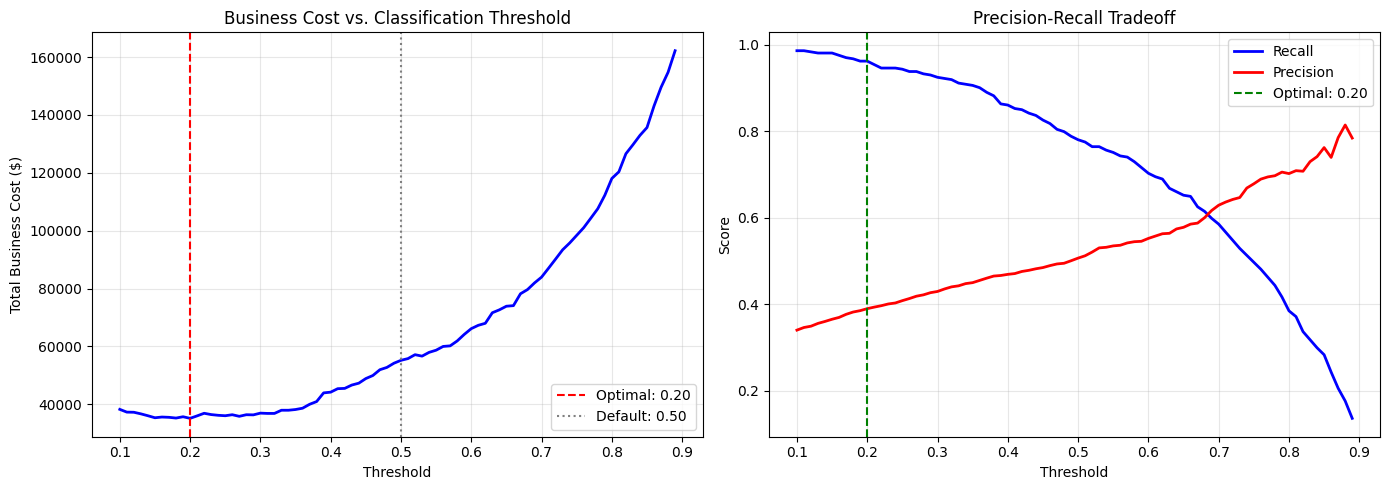

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cost_fp = 50   # Cost of false positive (wasted retention offer)
cost_fn = 500  # Cost of false negative (lost customer LTV)

# Evaluate total business cost at each threshold
thresholds = np.arange(0.1, 0.9, 0.01)
costs = []
recalls = []
precisions = []

# Using the probabilities of the best model (Logistic Regression)
for t in thresholds:
    y_pred_t = (y_proba_lr >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()

    total_cost = fp * cost_fp + fn * cost_fn
    costs.append(total_cost)
    recalls.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    precisions.append(tp / (tp + fp) if (tp + fp) > 0 else 0)

# Find optimal threshold
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost = costs[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.2f}")
print(f"Minimum total cost: ${optimal_cost:,.0f}")
print(f"Recall at optimal threshold: {recalls[optimal_idx]:.3f}")
print(f"Precision at optimal threshold: {precisions[optimal_idx]:.3f}")

# Compare with default threshold
default_idx = np.argmin(np.abs(thresholds - 0.5))
default_cost = costs[default_idx]
savings = default_cost - optimal_cost
print(f"\nDefault threshold (0.5) cost: ${default_cost:,.0f}")
print(f"Savings from optimization: ${savings:,.0f}")

# Plot cost vs threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, costs, "b-", linewidth=2)
axes[0].axvline(optimal_threshold, color="r", linestyle="--",
                label=f"Optimal: {optimal_threshold:.2f}")
axes[0].axvline(0.5, color="gray", linestyle=":", label="Default: 0.50")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Total Business Cost ($)")
axes[0].set_title("Business Cost vs. Classification Threshold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot precision-recall tradeoff
axes[1].plot(thresholds, recalls, "b-", label="Recall", linewidth=2)
axes[1].plot(thresholds, precisions, "r-", label="Precision", linewidth=2)
axes[1].axvline(optimal_threshold, color="green", linestyle="--",
                label=f"Optimal: {optimal_threshold:.2f}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Precision-Recall Tradeoff")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../docs/figures/cost_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. MLflow Baseline Models Registration

Files:
- `src/models/mlp.py` contains `ChurnMLP`, the Multi-Layer Perceptron for binary churn classification designed in step 1 above.
- `src/models/train.py` bundles the procedure to train `ChurnMLP` inside the function `train_mlp`.
- `src/models/mlp_baseline.py` is a script to run the MLflow experiment comparing the 3 baseline models against the MLP one.

All results, metrics, charts (confusion matrix, ROC, and PR curves), and the models themselves, are automatically logged to MLflow for experiment tracking and reproducibility.

**Running the experiments in mlflow server**

Prepare the mlflow server in another terminal:

```lang=shell
$ mlflow ui --port 5001
Backend store URI not provided. Using sqlite:///mlflow.db
Registry store URI not provided. Using backend store URI.
[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
2026/04/21 07:02:24 INFO:     Uvicorn running on http://127.0.0.1:5001 (Press CTRL+C to quit)
2026/04/21 07:02:24 INFO:     Started parent process [7819]
2026/04/21 07:02:27 INFO:     Started server process [7823]
2026/04/21 07:02:27 INFO:     Waiting for application startup.
2026/04/21 07:02:27 INFO:     Application startup complete.
2026/04/21 07:02:27 INFO:     Started server process [7825]
2026/04/21 07:02:27 INFO:     Waiting for application startup.
2026/04/21 07:02:27 INFO:     Application startup complete.
2026/04/21 07:02:27 INFO:     Started server process [7822]
2026/04/21 07:02:27 INFO:     Waiting for application startup.
2026/04/21 07:02:27 INFO:     Application startup complete.
2026/04/21 07:02:27 INFO:     Started server process [7824]
2026/04/21 07:02:27 INFO:     Waiting for application startup.
2026/04/21 07:02:27 INFO:     Application startup complete.
2026/04/21 07:02:30 INFO mlflow.server.jobs.utils: Registered online_scoring_scheduler periodic task (runs every 1 minute)
```

Run the training script:

In [1]:
%cd ..
!python -m src.models.mlp_baselines

/home/thiago/fiap/churn-prediction
2026-04-21 09:22:53 | src.features.preprocessing | INFO | Split: train=5634, test=1409, churn_rate_train=0.265, churn_rate_test=0.265
INFO:src.features.preprocessing:Split: train=5634, test=1409, churn_rate_train=0.265, churn_rate_test=0.265
2026-04-21 09:22:53 | src.features.preprocessing | INFO | TotalChargesFixer: learned median=1398.12
INFO:src.features.preprocessing:TotalChargesFixer: learned median=1398.12

Logistic Regression:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

accuracy: 0.738
precision: 0.504
recall: 0.783
f1: 0.614
pr_auc: 0.633
roc_auc: 0.841
2026/04/21 09:22:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04

The results will be available in `http://localhost:5001/`:

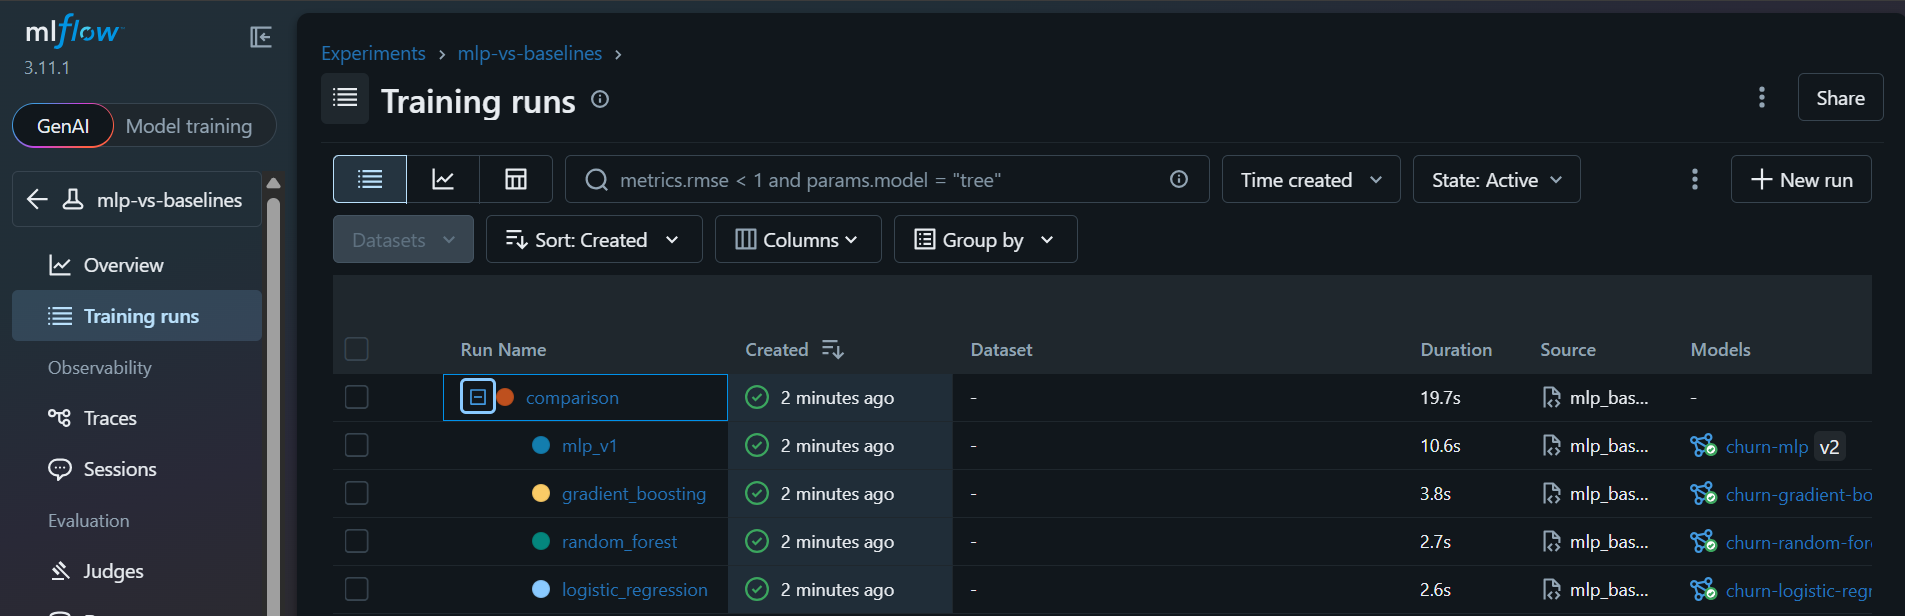

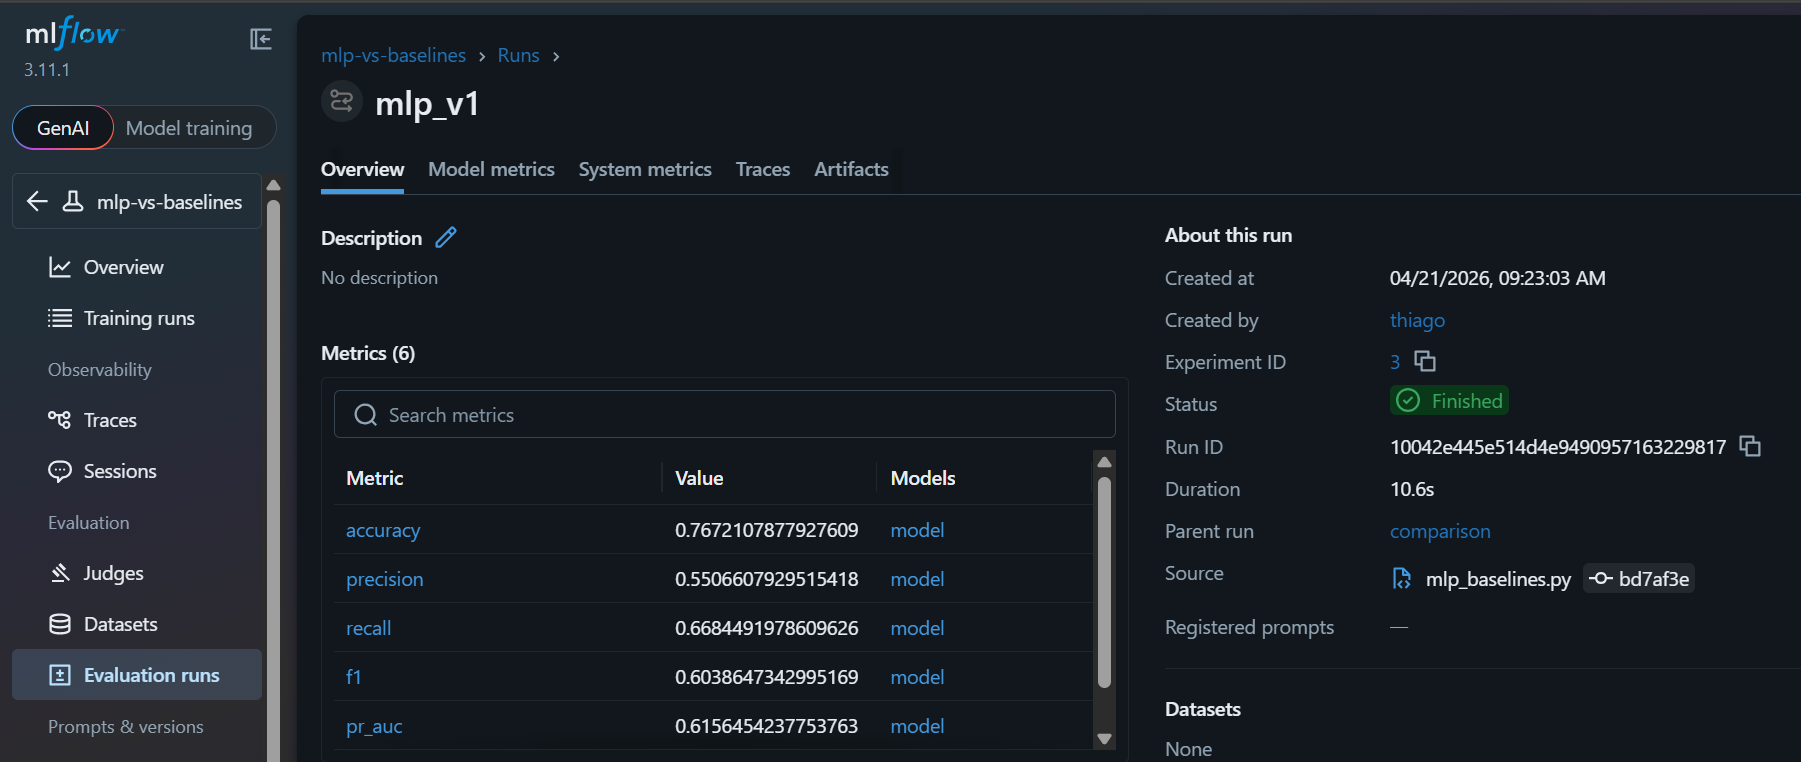